# GO Stanford (Multi-Trajectory Folders) → Cognitive Map Notebook
支持时间细胞风格 Sliding Window + Stride。


In [2]:
import os, re
from glob import glob
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

device='cuda' if torch.cuda.is_available() else 'cpu'
print('device=', device)


device= cuda


## 1. Multi-Trajectory Dataset (Time-Cell Style)
遍历每个轨迹子文件夹，生成 sequence 样本。


In [3]:
def sort_key(path):
    nums = re.findall(r'\d+', os.path.basename(path))
    return int(nums[-1]) if nums else 0

# 修改第 1 部分的 Dataset 代码
class GoStanfordMultiTrajDataset(Dataset):
    def __init__(self, root, split='train', seq_len=8, stride=2, transform=None, max_traj=None, max_frames=None):
        self.seq_len = seq_len
        self.stride = stride
        self.transform = transform

        split_dir = os.path.join(root, split) if split else root
        traj_dirs = sorted([d for d in glob(split_dir + '/*') if os.path.isdir(d)])
        
        if max_traj:
            traj_dirs = traj_dirs[:max_traj]

        self.sequences = []
        # 新增：保存原始轨迹的完整路径信息，用于评估和画图
        self.raw_trajectories = [] 

        for traj in traj_dirs:
            # 获取该轨迹下所有图片并排序
            frames = sorted(glob(os.path.join(traj, '*.jpg')), key=sort_key)
            if max_frames:
                frames = frames[:max_frames]
            
            # 只有长度足够的轨迹才被记录
            if len(frames) >= seq_len:
                # 保存原始轨迹信息
                self.raw_trajectories.append({
                    'id': os.path.basename(traj),
                    'paths': frames
                })
                
                # 生成训练用的滑动窗口
                for i in range(0, len(frames)-seq_len, stride):
                    self.sequences.append(frames[i:i+seq_len])

        print(f"Loaded {len(self.sequences)} sequences from {len(self.raw_trajectories)} trajectories")

    def __len__(self): return len(self.sequences)

    def __getitem__(self, idx):
        imgs = []
        for path in self.sequences[idx]:
            img = Image.open(path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            imgs.append(img)
        return torch.stack(imgs)


## 2. Backbone & World Model


In [4]:
class CognitiveBackbone(nn.Module):
    def __init__(self, arch='resnet18', pretrained=True, embed_dim=256):
        super().__init__()
        if arch=='resnet18': net=models.resnet18(pretrained=pretrained); dim=512
        elif arch=='resnet50': net=models.resnet50(pretrained=pretrained); dim=2048
        else: raise ValueError
        self.encoder=nn.Sequential(*list(net.children())[:-2])
        self.pool=nn.AdaptiveAvgPool2d((1,1))
        self.projector=nn.Sequential(nn.Linear(dim,512), nn.ReLU(), nn.Linear(512,embed_dim))
    def forward(self,x):
        f=self.encoder(x); f=self.pool(f).flatten(1)
        z=F.normalize(self.projector(f), dim=1)
        return z

class WorldModel(nn.Module):
    def __init__(self, d=256):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(d,512), nn.ReLU(), nn.Linear(512,d))
    def forward(self,z): return self.net(z)


## 3. Tiny TEM Memory (Placeholder)


In [75]:
class TinyTEM(nn.Module):
    def __init__(self, d=256, capacity=5000): super().__init__(); self.capacity=capacity; self.reset()
    def reset(self): self.mem=[]
    def forward(self,z):
        self.mem.append(z.detach().cpu())
        if len(self.mem)>self.capacity: self.mem=self.mem[-self.capacity:]
        return z
    def get_map(self): return torch.cat(self.mem, dim=0) if len(self.mem)>0 else None


## 4. Training


In [76]:
ROOT = os.environ.get('GOSTANFORD_ROOT', '/media/zhen/Data/Datasets/nomad_data/go_stanford')
SEQ=20; STRIDE=2; BATCH=8; EPOCH=20

tfm=T.Compose([
    T.Resize((224,224)), T.ToTensor(),
    T.Normalize([.485,.456,.406],[.229,.224,.225])
])

ds=GoStanfordMultiTrajDataset(ROOT, split='', seq_len=SEQ, stride=STRIDE, transform=tfm,
                              max_traj=10, max_frames=150)
dl=DataLoader(ds, batch_size=BATCH, shuffle=True)

enc=CognitiveBackbone(embed_dim=256).to(device)
wm=WorldModel(256).to(device)
tem=TinyTEM(256)

opt=torch.optim.Adam(list(enc.parameters())+list(wm.parameters()), lr=1e-4)
mse=nn.MSELoss()

for ep in range(EPOCH):
    tot=0
    for seq in dl:
        B,T,C,H,W=seq.shape
        seq=seq.to(device)
        z=enc(seq.view(B*T,C,H,W)).view(B,T,-1)
        pred=wm(z[:,:-1])
        loss=mse(pred, z[:,1:])
        opt.zero_grad(); loss.backward(); opt.step()
        tot+=loss.item()
    print('epoch',ep,'loss',tot/len(dl))


Loaded 120 sequences from 4 trajectories


/media/zhen/Share/anaconda3/envs/cogmap_torchtem/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/media/zhen/Share/anaconda3/envs/cogmap_torchtem/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


epoch 0 loss 0.0024682492949068546
epoch 1 loss 0.000448748659012684
epoch 2 loss 5.3634075932980825e-05
epoch 3 loss 2.205137388955336e-05
epoch 4 loss 8.725051793589956e-06
epoch 5 loss 5.022790871104614e-06
epoch 6 loss 3.737601158112132e-06
epoch 7 loss 3.0721870795484088e-06
epoch 8 loss 2.4787911722038796e-06
epoch 9 loss 2.0564439334217846e-06
epoch 10 loss 1.8059243908889282e-06
epoch 11 loss 1.5205087644668917e-06
epoch 12 loss 1.3348807897273218e-06
epoch 13 loss 1.2509060752563527e-06
epoch 14 loss 1.0974562390705007e-06
epoch 15 loss 1.0439097801887935e-06
epoch 16 loss 9.297173088877268e-07
epoch 17 loss 8.341965932838017e-07
epoch 18 loss 7.756043184296383e-07
epoch 19 loss 7.427921673297533e-07


## 5. Cognitive Map Visualization (One Trajectory)


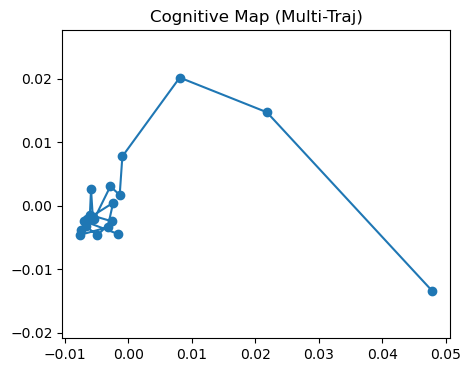

In [77]:
tem.reset()
sample = ds[0].unsqueeze(0).to(device)
B,T,C,H,W=sample.shape
with torch.no_grad():
    z=enc(sample.view(B*T,C,H,W)).view(B,T,-1)[0]
    for t in range(T): tem(z[t:t+1])

MAP=tem.get_map().numpy()
Z2=PCA(2).fit_transform(MAP)

plt.figure(figsize=(5,4))
plt.plot(Z2[:,0], Z2[:,1], '-o')
plt.title('Cognitive Map (Multi-Traj)')
plt.axis('equal'); plt.show()


In [78]:
# 在文件末尾添加以下新功能

# 替换第 5 部分的 MultiTrajectoryEvaluator
from torch.utils.data import TensorDataset
from sklearn.decomposition import PCA
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image

class MultiTrajectoryEvaluator:
    def __init__(self, encoder, world_model, tem_capacity=5000, eval_batch_size=32):
        self.encoder = encoder
        self.world_model = world_model
        self.tem = TinyTEM(256, capacity=tem_capacity)
        self.eval_batch_size = eval_batch_size
        
    def evaluate_trajectory(self, trajectory_data, device):
        """
        分批次评估单个轨迹
        """
        self.encoder.eval()
        self.world_model.eval()
        
        T_total = trajectory_data.size(0)
        if T_total < 2: return None
        
        # --- 分批次通过 Encoder ---
        temp_dataset = TensorDataset(trajectory_data)
        temp_loader = DataLoader(temp_dataset, batch_size=self.eval_batch_size, shuffle=False)
        
        z_list = []
        
        with torch.no_grad():
            for (batch_imgs,) in temp_loader:
                batch_imgs = batch_imgs.to(device)
                z_batch = self.encoder(batch_imgs) 
                z_list.append(z_batch)
            
            z = torch.cat(z_list, dim=0) 
            
            # 预测下一时刻
            if T_total > 1:
                z_dev = z.to(device)
                z_pred = self.world_model(z_dev[:-1])
                z_true = z_dev[1:]
                
                mse_error = F.mse_loss(z_pred, z_true).item()
                cos_sim = F.cosine_similarity(z_pred, z_true, dim=1).mean().item()
            else:
                mse_error = 0; cos_sim = 1

            # --- 更新 TEM 记忆 (确保在 CPU 上进行以节省显存) ---
            for t in range(T_total):
                self.tem(z[t:t+1].detach().cpu()) 
                
        return {
            'length': T_total,
            'mse_error': mse_error,
            'cosine_similarity': cos_sim
        }
    
    def build_cognitive_map(self, dataset, device, max_trajectories=None):
        self.tem.reset()
        trajectory_metrics = []
        processed_count = 0
        
        # 使用 dataset.raw_trajectories
        traj_list = dataset.raw_trajectories
        if max_trajectories:
            traj_list = traj_list[:max_trajectories]
            
        print(f"Processing {len(traj_list)} full trajectories...")
        
        for traj_info in traj_list:
            traj_id = traj_info['id']
            paths = traj_info['paths']
            
            frames = []
            for path in paths:
                try:
                    img = Image.open(path).convert('RGB')
                    if dataset.transform:
                        img = dataset.transform(img)
                    frames.append(img)
                except Exception as e:
                    print(f"Error loading {path}: {e}")
            
            if not frames: continue
                
            trajectory_tensor = torch.stack(frames)
            metrics = self.evaluate_trajectory(trajectory_tensor, device)
            
            if metrics:
                metrics['trajectory_id'] = traj_id
                trajectory_metrics.append(metrics)
                processed_count += 1
                print(f"  Traj {traj_id}: Length={metrics['length']}, MSE={metrics['mse_error']:.4f}")
        
        # --- 补回缺失的 PCA 计算部分 ---
        cognitive_map = self.tem.get_map()
        map_2d = None
        map_3d = None
        
        if cognitive_map is not None and len(cognitive_map) > 0:
            # 转换为 numpy
            map_numpy = cognitive_map.detach().cpu().numpy()
            
            # 计算 2D 投影
            if map_numpy.shape[0] >= 2:
                try:
                    pca_2d = PCA(n_components=2)
                    map_2d = pca_2d.fit_transform(map_numpy)
                except Exception as e:
                    print(f"PCA 2D failed: {e}")
            
            # 计算 3D 投影 (可选)
            if map_numpy.shape[0] >= 3:
                try:
                    pca_3d = PCA(n_components=3)
                    map_3d = pca_3d.fit_transform(map_numpy)
                except Exception:
                    pass

        return {
            'cognitive_map': cognitive_map,
            'trajectory_metrics': trajectory_metrics,
            'processed_trajectories': processed_count,
            'map_2d': map_2d,  # 现在这里有值了
            'map_3d': map_3d
        }

def visualize_multi_trajectory_map(evaluation_result, title="Multi-Trajectory Cognitive Map"):
    """
    可视化多轨迹认知地图
    
    Args:
        evaluation_result: 评估结果字典
        title: 图标题
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 2D认知地图
    if evaluation_result['map_2d'] is not None:
        axes[0].scatter(evaluation_result['map_2d'][:, 0], 
                       evaluation_result['map_2d'][:, 1], 
                       alpha=0.6, s=20)
        axes[0].set_title(f"{title} (2D)")
        axes[0].set_xlabel("PC1")
        axes[0].set_ylabel("PC2")
        axes[0].grid(True)
    
    # 性能指标统计
    if evaluation_result['trajectory_metrics']:
        metrics = evaluation_result['trajectory_metrics']
        mse_errors = [m['mse_error'] for m in metrics]
        cos_sims = [m['cosine_similarity'] for m in metrics]
        
        axes[1].hist(mse_errors, bins=20, alpha=0.7, label='MSE Error')
        axes[1].set_title("Prediction Error Distribution")
        axes[1].set_xlabel("MSE")
        axes[1].set_ylabel("Frequency")
        axes[1].legend()
        axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

def print_evaluation_summary(evaluation_result):
    """
    打印评估摘要
    
    Args:
        evaluation_result: 评估结果字典
    """
    metrics = evaluation_result['trajectory_metrics']
    if not metrics:
        print("No trajectories were processed.")
        return
    
    avg_mse = np.mean([m['mse_error'] for m in metrics])
    avg_cos_sim = np.mean([m['cosine_similarity'] for m in metrics])
    total_states = sum([m['length'] for m in metrics])
    
    print("=" * 50)
    print("MULTI-TRAJECTORY EVALUATION SUMMARY")
    print("=" * 50)
    print(f"Processed trajectories: {evaluation_result['processed_trajectories']}")
    print(f"Total states in map: {total_states}")
    print(f"Average prediction MSE: {avg_mse:.6f}")
    print(f"Average cosine similarity: {avg_cos_sim:.4f}")
    print("=" * 50)


Loaded 120 sequences from 4 trajectories
Processing 4 full trajectories...
  Traj no10vcF_10_0: Length=68, MSE=0.0000
  Traj no10vcF_18_0: Length=54, MSE=0.0000
  Traj no10vcF_22_0: Length=150, MSE=0.0000
  Traj no10vcF_26_0: Length=48, MSE=0.0000
MULTI-TRAJECTORY EVALUATION SUMMARY
Processed trajectories: 4
Total states in map: 320
Average prediction MSE: 0.000001
Average cosine similarity: 0.9999


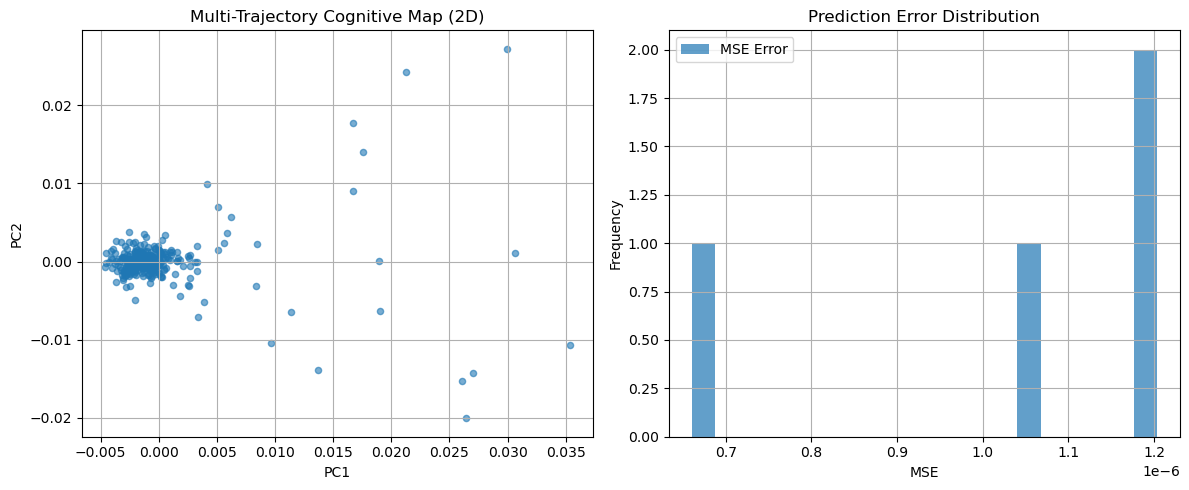


First trajectory details:
  ID: no10vcF_10_0
  Length: 68 states
  MSE error: 0.000001
  Cosine similarity: 0.9999


In [79]:

# 重新初始化 Dataset (为了让新的 __init__ 生效)
ds = GoStanfordMultiTrajDataset(ROOT, split='', seq_len=SEQ, stride=STRIDE, transform=tfm,
                              max_traj=10, max_frames=150)

# 创建评估器 (设置 eval_batch_size 以控制显存)
evaluator = MultiTrajectoryEvaluator(enc, wm, tem_capacity=10000, eval_batch_size=32)

# 执行
try:
    eval_result = evaluator.build_cognitive_map(ds, device, max_trajectories=5)
    print_evaluation_summary(eval_result)
    visualize_multi_trajectory_map(eval_result)
except Exception as e:
    print(f"An error occurred: {e}")
    import traceback
    traceback.print_exc()

    
# 也可以单独查看某个轨迹的表现
if eval_result['trajectory_metrics']:
    first_traj = eval_result['trajectory_metrics'][0]
    print(f"\nFirst trajectory details:")
    print(f"  ID: {first_traj['trajectory_id']}")
    print(f"  Length: {first_traj['length']} states")
    print(f"  MSE error: {first_traj['mse_error']:.6f}")
    print(f"  Cosine similarity: {first_traj['cosine_similarity']:.4f}")
